# Phase 7 — Orchestrator + FastAPI + event store

> *The propose half meets the dispose half — and every decision is logged.*

This is where the whole system comes together. The reward model (Phase 3) and bandit (Phase 4)
**propose** actions; the TSP-with-Profits router (Phase 6) **disposes** them into a walkable
route. The `Orchestrator` is the seam, and a thin FastAPI service exposes it over HTTP, backed by
an **append-only** event store whose propensity log later feeds the OPE gate (Phase 5).

We mirror `src/nba/pipeline/` and `src/nba/api/`:

1. **Assemble the loop** — policy + reward model + distance engine + store → `Orchestrator`.
2. **The online loop** — `recommend` logs a decision (with its propensity); `feedback` appends an
   outcome.
3. **Append-only** — corrections are *new* rows; the latest wins; the audit trail is intact.
4. **The seam** — `plan_route` prices each door by its **bandit-weighted** value and routes it.
5. **The HTTP edge** — `/recommend`, `/feedback`, `/route`, `/health` via a `TestClient`.
6. **Closing the loop** — `load_events` hands labeled data straight back to training and OPE.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nba.api.store import EventStore
from nba.bandits.epsilon_greedy import EpsilonGreedy
from nba.config import Settings
from nba.data.simulator import frame_to_events
from nba.pipeline.orchestrator import Orchestrator
from nba.reward.model import RewardModel
from nba.routing.distance import HaversineEngine
from nba.schema import Outcome

SEED = 7
RNG = np.random.default_rng(SEED)

# === Dataset selection — toggle this one line to switch flat <-> relational ===
DATASET_MODE = "relational"  # "flat" | "relational"
_logs = {"flat": "data/logs.parquet", "relational": "data/relational/logs.parquet"}[DATASET_MODE]
_models = {"flat": "artifacts/models", "relational": "artifacts/models/relational"}[DATASET_MODE]
DATA_PATH = next((p for p in (Path(_logs), Path("..") / _logs) if p.exists()), Path(_logs))
MODEL_DIR = next((p for p in (Path(_models), Path("..") / _models) if p.exists()), Path(_models))

model = RewardModel.load(MODEL_DIR)
contexts = [e.context for e in frame_to_events(pd.read_parquet(DATA_PATH))]

# A throwaway SQLite file so the notebook never pollutes the real event log.
tmp_db = Path(tempfile.mkdtemp()) / "events.db"
settings = Settings(db_path=tmp_db)

orch = Orchestrator(
    policy=EpsilonGreedy(model, epsilon=settings.epsilon, rng=RNG),
    reward_model=model,
    distance_engine=HaversineEngine(speed_kmh=settings.walking_speed_kmh),
    store=EventStore(settings.db_path),
    settings=settings,
)
print("orchestrator policy :", orch.policy_name)
print("event store         :", settings.db_path)
print(f"loaded model + {len(contexts):,} candidate doors")


def make_oracle(ctxs):
    """Dataset-aware grading oracle (eval-only). Relational mode binds a world to the doors."""
    from nba.config import Settings
    from nba.eval.oracle import oracle_for

    _s = Settings(dataset_mode=DATASET_MODE, seed=SEED)
    if DATASET_MODE == "relational":
        from nba.data.relational_simulator import world_from_contexts

        return oracle_for(_s, world=world_from_contexts(list(ctxs), settings=_s, seed=SEED))
    return oracle_for(_s)

orchestrator policy : epsilon_greedy
event store         : /tmp/tmpknj36jab/events.db
loaded model + 100,000 candidate doors


## 1. The online loop: `recommend` → `feedback`

`recommend(ctx)` asks the policy for an action, **logs the decision and its propensity**, and
returns a `decision_id`. The propensity `p(action | context)` is the overlap guarantee that makes
the log replayable by off-policy evaluation — it is never null.

In [2]:
sample = [contexts[i] for i in RNG.choice(len(contexts), size=10, replace=False)]
results = [orch.recommend(ctx) for ctx in sample]

table = pd.DataFrame(
    {
        "decision_id": [r.decision_id[:8] + "…" for r in results],
        "action": [r.action.value for r in results],
        "propensity": [round(r.propensity, 3) for r in results],
        "q(best)": [round(max(r.q_values.values()), 3) for r in results],
    }
)
print(table.to_string(index=False))
print(f"\ndecisions logged: {orch.decision_count()}")
assert all(r.propensity > 0 for r in results), "every decision must log p > 0"

decision_id         action  propensity  q(best)
  ed69a4f4…    pitch_solar        0.92    0.118
  7349cc61…    pitch_solar        0.92    0.198
  3c9c2e68…      knock_now        0.92    0.251
  0b433fe3…    pitch_solar        0.92    0.198
  e269f4f3…    pitch_solar        0.32    0.163
  2ef83873…    pitch_solar        0.92    0.265
  e72c3112… pitch_security        0.02    0.037
  dd7161a0…      knock_now        0.92    0.118
  d57c6030…    pitch_solar        0.92    0.198
  147d2518… pitch_security        0.02    0.281

decisions logged: 10


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

Now we close each decision with an **observed outcome**. In production this is a rep tapping
"appointment booked"; here we draw from the simulator's ground truth. `feedback` appends an
outcome row and derives its reward from the reward map.

In [3]:
oracle = make_oracle(contexts)
for ctx, r in zip(sample, results, strict=True):
    outcome = oracle.sample_outcome(ctx, r.action, RNG)
    orch.feedback(r.decision_id, outcome)

events = orch._store.load_events()  # noqa: SLF001 - peeking at the store for illustration
labeled = [e for e in events if e.reward is not None]
print(f"decisions: {orch.decision_count()}   outcomes: {orch._store.outcome_count()}")  # noqa: SLF001
print(f"labeled events ready for training/OPE: {len(labeled)}")
print("\nexample reconstructed event:")
e = labeled[0]
print(
    f"  action={e.action.value}  outcome={e.outcome.value}  "
    f"reward={e.reward:+.2f}  p={e.propensity:.3f}"
)

decisions: 10   outcomes: 10
labeled events ready for training/OPE: 10

example reconstructed event:
  action=pitch_solar  outcome=not_home  reward=+0.00  p=0.920


## 2. Append-only: corrections never overwrite history

The store issues **no `UPDATE` or `DELETE`**. If a rep corrects an outcome, that's a *new* row;
`load_events` takes the latest by id. Both rows survive, so the audit trail (and the logged
propensities OPE depends on) stays honest.

In [4]:
target = results[0].decision_id

before = orch._store.outcome_count()  # noqa: SLF001
orch.feedback(target, Outcome.SLAMMED)  # first correction
orch.feedback(target, Outcome.CLOSED)  # second correction — this one should win
after = orch._store.outcome_count()  # noqa: SLF001

latest = next(e for e in orch._store.load_events() if e.decision_id == target)  # noqa: SLF001
print(f"outcome rows: {before} → {after}  (both corrections retained, nothing overwritten)")
print(
    f"latest-wins outcome for {target[:8]}…: {latest.outcome.value} (reward {latest.reward:+.2f})"
)

outcome rows: 10 → 12  (both corrections retained, nothing overwritten)
latest-wins outcome for ed69a4f4…: closed (reward +1.00)


## 3. The seam: bandit-weighted profit → walkable route

`plan_route` prices each door by the bandit's **expected** value —
$\text{profit}_d = \sum_a \pi(a \mid x_d)\, \hat q(x_d, a)$ — so exploration value flows into
routing rather than a hard argmax. Those profits become drop penalties in the TSP-with-Profits
solver, which then drops far, low-value doors. (A rep works a dense neighborhood, so we route the
doors nearest a chosen center.)

In [5]:
# Pick a dense, walkable neighborhood: the N doors nearest a random center.
def haversine_km(center, pts):
    radius = 6371.0088
    lat1, lon1 = np.radians(center)
    lat2, lon2 = np.radians(pts[:, 0]), np.radians(pts[:, 1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))


# Center on a real door, then take its 60 nearest neighbors from the FULL door set so the cluster is
# genuinely walkable. (Sampling the center from a small random subsample can land in a sparse area
# where the "nearest" doors are still ~600 m apart, so TSP-P rightly drops them all — see below.)
all_coords = np.array([(c.lat, c.lon) for c in contexts])
center = all_coords[RNG.integers(len(all_coords))]
nearest = np.argsort(haversine_km(center, all_coords))[:60]
doors = [contexts[i] for i in nearest]

route = orch.plan_route(doors)
print(f"candidate doors : {len(doors)}")
print(f"  visited       : {len(route.visited)}")
print(f"  dropped       : {len(route.dropped)}")
print(f"  walk+dwell    : {route.total_time_s / 60:.1f} min")
print(f"  profit        : {route.total_profit:.2f}")

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

candidate doors : 60
  visited       : 40
  dropped       : 20
  walk+dwell    : 92.0 min
  profit        : 7.51


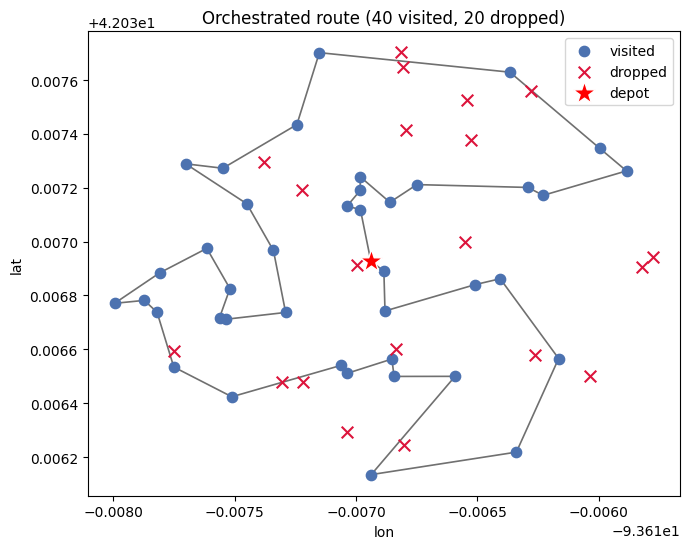

In [6]:
# depot is index 0 (centroid of the doors); doors are indices 1..n.
coords = np.array(
    [(np.mean([c.lat for c in doors]), np.mean([c.lon for c in doors]))]
    + [(c.lat, c.lon) for c in doors]
)

fig, ax = plt.subplots(figsize=(7, 5.6))
vis = np.array(route.visited, dtype=int)
if vis.size:
    ax.scatter(coords[vis, 1], coords[vis, 0], c="#4C72B0", s=55, zorder=3, label="visited")
if route.dropped:
    dr = np.array(route.dropped, dtype=int)
    ax.scatter(
        coords[dr, 1], coords[dr, 0], marker="x", c="crimson", s=70, zorder=3, label="dropped"
    )
path = coords[route.order]
ax.plot(path[:, 1], path[:, 0], "-", color="#333333", lw=1.2, alpha=0.7, zorder=2)
ax.scatter(
    coords[0, 1],
    coords[0, 0],
    marker="*",
    c="red",
    s=300,
    edgecolor="white",
    zorder=4,
    label="depot",
)
ax.set(
    title=f"Orchestrated route ({len(route.visited)} visited, {len(route.dropped)} dropped)",
    xlabel="lon",
    ylabel="lat",
)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

### Bandit-weighted vs. argmax profit

The expected-value pricing is deliberate: a door where the bandit is *unsure* (mass spread over
several actions) is valued by its whole distribution, not just the top arm. The toggle
`argmax_profit=True` recovers the greedy alternative. They usually agree on ranking but differ in
magnitude — the weighted price is a touch more conservative.

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

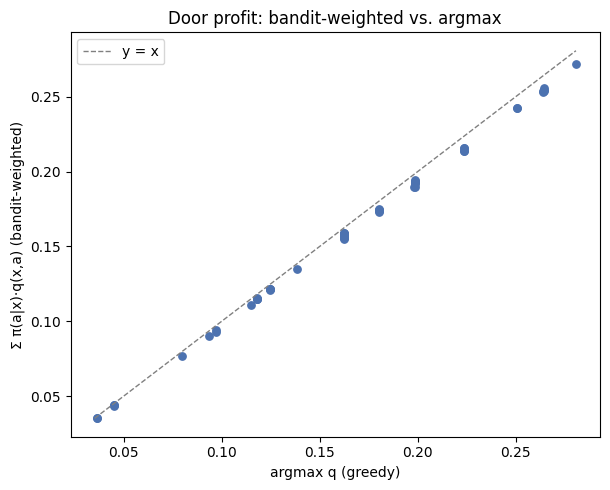

weighted ≤ argmax for 100% of doors (expected: weighting can only lower the max)


In [7]:
orch_argmax = Orchestrator(
    policy=orch._policy,
    reward_model=model,  # noqa: SLF001
    distance_engine=HaversineEngine(speed_kmh=settings.walking_speed_kmh),
    store=orch._store,
    settings=settings,
    argmax_profit=True,  # noqa: SLF001
)
weighted = np.array([orch.door_profit(c) for c in doors])
argmax = np.array([orch_argmax.door_profit(c) for c in doors])

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.scatter(argmax, weighted, s=28, color="#4C72B0")
lim = [min(argmax.min(), weighted.min()), max(argmax.max(), weighted.max())]
ax.plot(lim, lim, "--", color="gray", lw=1, label="y = x")
ax.set(
    title="Door profit: bandit-weighted vs. argmax",
    xlabel="argmax q (greedy)",
    ylabel="Σ π(a|x)·q(x,a) (bandit-weighted)",
)
ax.legend()
plt.tight_layout()
plt.show()
print(
    f"weighted ≤ argmax for {100 * np.mean(weighted <= argmax + 1e-9):.0f}% of doors "
    f"(expected: weighting can only lower the max)"
)

## 4. The HTTP edge

`build_app(orchestrator)` wraps the orchestrator in a FastAPI app. We drive it with FastAPI's
`TestClient` (no server needed). Note the symmetry: each endpoint is a thin adapter over an
orchestrator method.

In [8]:
from fastapi.testclient import TestClient  # noqa: E402

from nba.api.app import build_app  # noqa: E402

client = TestClient(build_app(orch))

print("GET /health  →", client.get("/health").json())

ctx_json = doors[0].model_dump(mode="json")
rec = client.post("/recommend", json={"context": ctx_json}).json()
print("\nPOST /recommend →")
print(
    f"  decision_id={rec['decision_id'][:8]}…  action={rec['action']}  "
    f"propensity={rec['propensity']:.3f}"
)

fb = client.post("/feedback", json={"decision_id": rec["decision_id"], "outcome": "appointment"})
print(f"\nPOST /feedback  → HTTP {fb.status_code} (204 = logged, no body)")

resp = client.post("/route", json={"contexts": [c.model_dump(mode="json") for c in doors]}).json()
print(
    f"\nPOST /route     → {len(resp['stops'])} stops, {len(resp['dropped'])} dropped, "
    f"{resp['total_time_s'] / 60:.1f} min, profit {resp['total_profit']:.2f}"
)
print("  first 3 stops:", [(s["address_id"], s["order"]) for s in resp["stops"][:3]])

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X

GET /health  → {'status': 'ok', 'policy': 'epsilon_greedy', 'decisions': 10}

POST /recommend →
  decision_id=3094b6e9…  action=knock_now  propensity=0.920

POST /feedback  → HTTP 204 (204 = logged, no body)


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa


POST /route     → 40 stops, 20 dropped, 92.0 min, profit 7.51
  first 3 stops: [('00000000-0000-0000-6f22-9f1b8da86964', 0), ('00000000-0000-0000-1e4f-e3600001be71', 1), ('00000000-0000-0000-6d2c-27de3feb6f47', 2)]


In [9]:
# Error handling: unknown decision_id → 404, malformed body → 422.
print(
    "unknown decision_id →",
    client.post("/feedback", json={"decision_id": "nope", "outcome": "info_given"}).status_code,
)
print(
    "malformed context   →",
    client.post("/recommend", json={"context": {"address_id": "x"}}).status_code,
)

unknown decision_id → 404
malformed context   → 422


## 5. Closing the loop

Everything `recommend` logged is replayable. `store.load_events()` returns exactly the
`BanditEvent`s that Phase 3 trains on and Phase 5 evaluates — same schema, same propensities. The
service *is* the data generator for the next model.

In [10]:
final = orch._store.load_events()  # noqa: SLF001
labeled = [e for e in final if e.reward is not None]
print(f"total decisions logged : {len(final)}")
print(f"labeled & replayable    : {len(labeled)}")
print(f"mean logged reward      : {np.mean([e.reward for e in labeled]):+.3f}")
print(
    "\nThese events drop straight back into RewardModel.fit(...) and LoggedBatch.from_events(...)."
)

total decisions logged : 11
labeled & replayable    : 11
mean logged reward      : +0.200

These events drop straight back into RewardModel.fit(...) and LoggedBatch.from_events(...).


## 6. Takeaways

- **One seam, dependency-injected.** The `Orchestrator` is pure Python; the API only adapts HTTP
  to its methods, so the same loop is testable with a `TestClient` and a fake model.
- **Every decision logs its propensity.** That single discipline is what lets the OPE gate later
  estimate a new policy's value from these very logs.
- **Append-only by construction.** Corrections add rows; the latest wins; nothing is overwritten —
  an honest, auditable trail.
- **Bandit-weighted profit is the seam's key choice.** Routing sees the policy's *expected* door
  value, so exploration flows through to where the rep actually walks.
- **The loop closes.** `load_events` returns training/OPE-ready `BanditEvent`s: serve → log →
  retrain → evaluate → promote → serve.